In [ ]:
import sys, os
from pathlib import Path

parent_folder = str(Path.cwd().parents[2])
if parent_folder not in sys.path:
    sys.path.append(parent_folder)
from sigpy import mri
import scipy
import pickle
from sklearn.decomposition import PCA
from matplotlib.colors import ListedColormap
import seaborn as sns
import sigpy as sp
import cupy as cp
import numpy as np
from sigpy.mri.app import L1WaveletRecon


## My files
import save_data_helpers
import recon_functions
import recon_plot_helpers
from gating_functions import golden_angle_coords_3d
import sigpy.plot as pl

In [2]:
idx, resp_trimmed, data_bins, spoke_bins, index_bins = save_data_helpers.load_gate_outputs_pickle('/home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl')
print(f'data_bins[0].shape = {data_bins[0].shape}')
print(f'spoke_bins[0].shape = {spoke_bins[0].shape}')

ksp_gate0 = data_bins[0]
coords_gate0 = spoke_bins[0]
ncoils, npts, nsamples = data_bins[0].shape
img_shape = (58, nsamples, nsamples)
print(f'img_shape = {img_shape}')

espirit_mps_gate0 = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/coils/subject2_mid0082/espirit_mps_full_res_ksp_512_ungated.pkl')
print(f'espirit_mps_gate0.shape = {espirit_mps_gate0.shape}')

dcf_ksp_5gates = save_data_helpers.read_pickle('/home/lilianae/projects/naf_clean/recons/subject2_mid0082/pkl_files_512/dcf_ksp_dense_512_5gates.pkl')
dcf_ksp_gate0 = dcf_ksp_5gates[0]
print(f'dcf_ksp_gate0.shape = {dcf_ksp_gate0.shape}')

ksp_gate0_with_dcf = ksp_gate0 * dcf_ksp_gate0[None,...]
print(f'ksp_gate0_with_dcf.shape = {ksp_gate0_with_dcf.shape}')

Loaded /home/lilianae/projects/naf_clean/load_data_clean/subject2_mid0082/gates_dense_amp_512.pkl
  idx shape: (113116,)
  signal_trimmed shape: (113116,)
  data_bins: 5 elements
  spoke_bins: 5 elements
  index_bins: 5 elements
data_bins[0].shape = (15, 22623, 512)
spoke_bins[0].shape = (22623, 512, 3)
img_shape = (58, 512, 512)
espirit_mps_gate0.shape = (15, 58, 512, 512)
dcf_ksp_gate0.shape = (22623, 512)
ksp_gate0_with_dcf.shape = (15, 22623, 512)


## Step 1: NUFFT

In [3]:

device = 1
COIL_BATCH_SIZE = 3
BATCH_SIZE = 1  # or 4-5,
num_coils = 15  # full dataset
mps = espirit_mps_gate0
nz, ny, nx = 58, 512, 512  # spatial dimensions
img_shape = (nz, ny, nx)

# Data loading
ksp = ksp_gate0_with_dcf # shape: (15, 58, 400, 512)
mps = espirit_mps_gate0  # shape: (15, 58, 512, 512)
coords = coords_gate0

nufft_coil_images_cpu = []  # Store on CPU

with sp.Device(device):
    # Process coils in batches
    for coil_start in range(0, num_coils, BATCH_SIZE):
        coil_end = min(coil_start + BATCH_SIZE, num_coils)
        batch_size_actual = coil_end - coil_start
        
        print(f'Processing NUFFT for coils {coil_start} to {coil_end-1}')
        
        # 1a. Get batch of kspace data and move to GPU
        ksp_batch = sp.to_device(ksp[coil_start:coil_end], device)
        
        # 1b. Create NUFFT operator for this batch
        batch_shape = (batch_size_actual, nz, ny, nx)
        F_batch = sp.linop.NUFFT(batch_shape, coord=coords)
        
        # 1c. Apply NUFFT adjoint (F.H) to get coil images
        nufft_batch_result = F_batch.H * ksp_batch
        
        # 1d. Normalize 
        nufft_batch_norm = np.zeros_like(nufft_batch_result)
        for i in range(batch_size_actual):
            img = np.abs(nufft_batch_result[i])
            nufft_batch_norm[i] = (img - np.min(img)) / (np.max(img) - np.min(img))
        
        # 1e. Move to CPU and store
        nufft_batch_cpu = cp.asnumpy(nufft_batch_norm)
        nufft_coil_images_cpu.append(nufft_batch_cpu)
        
        # 1f. Clean up GPU memory
        del ksp_batch, nufft_batch_result, nufft_batch_norm
        cp.get_default_memory_pool().free_all_blocks()

# Concatenate all coil images on CPU
nufft_res_norm_cpu = np.concatenate(nufft_coil_images_cpu, axis=0)  # (15, 58, 512, 512)
del nufft_coil_images_cpu

Processing NUFFT for coils 0 to 0
Processing NUFFT for coils 1 to 1
Processing NUFFT for coils 2 to 2
Processing NUFFT for coils 3 to 3
Processing NUFFT for coils 4 to 4
Processing NUFFT for coils 5 to 5
Processing NUFFT for coils 6 to 6
Processing NUFFT for coils 7 to 7
Processing NUFFT for coils 8 to 8
Processing NUFFT for coils 9 to 9
Processing NUFFT for coils 10 to 10
Processing NUFFT for coils 11 to 11
Processing NUFFT for coils 12 to 12
Processing NUFFT for coils 13 to 13
Processing NUFFT for coils 14 to 14


## 2. SENSE

In [4]:
## Try to batch SENSE operator too

with sp.Device(device):
    nufft_sense = cp.zeros(img_shape, dtype=np.complex64)
    # Move normalized NUFFT result and sensitivity maps to GPU

    ## Process SENSE in batches
    for coil_start in range(0, num_coils, COIL_BATCH_SIZE):
        coil_end = min(coil_start + COIL_BATCH_SIZE, num_coils)

        print(f'SENSE for coils {coil_start} to {coil_end-1}')

        ## Load this batch of coil images and sensitivity maps
        nufft_batch = sp.to_device(nufft_res_norm_cpu[coil_start:coil_end], device)
        mps_batch = sp.to_device(mps[coil_start:coil_end], device)

        ## Apply S.H for this batch
        for i in range(coil_end - coil_start):
            nufft_sense += cp.conj(mps_batch[i]) * nufft_batch[i]

        del nufft_batch, mps_batch
        cp.get_default_memory_pool().free_all_blocks()

    img = cp.abs(nufft_sense)
    nufft_sense_norm = (img - cp.min(img)) / (cp.max(img) - cp.min(img))
    
    del img, nufft_sense
    cp.get_default_memory_pool().free_all_blocks()

SENSE for coils 0 to 2
SENSE for coils 3 to 5
SENSE for coils 6 to 8
SENSE for coils 9 to 11
SENSE for coils 12 to 14


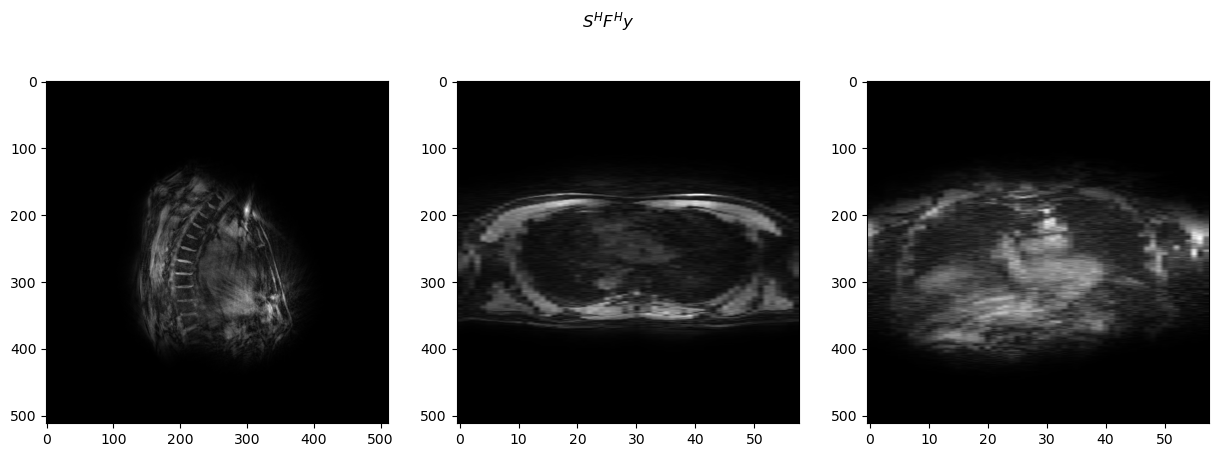

In [5]:
fig, axs = recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(nufft_sense_norm), title=rf'$S^H F^H y$')

## 3. Wavelet

In [6]:
with sp.Device(device):
    W = sp.linop.Wavelet(img_shape, wave_name='db4', level=4)
    wav_norm = W * nufft_sense_norm
    del nufft_sense_norm
    cp.get_default_memory_pool().free_all_blocks()


/home/lilianae/mambaforge/envs/jointrecon_env_backup_new/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


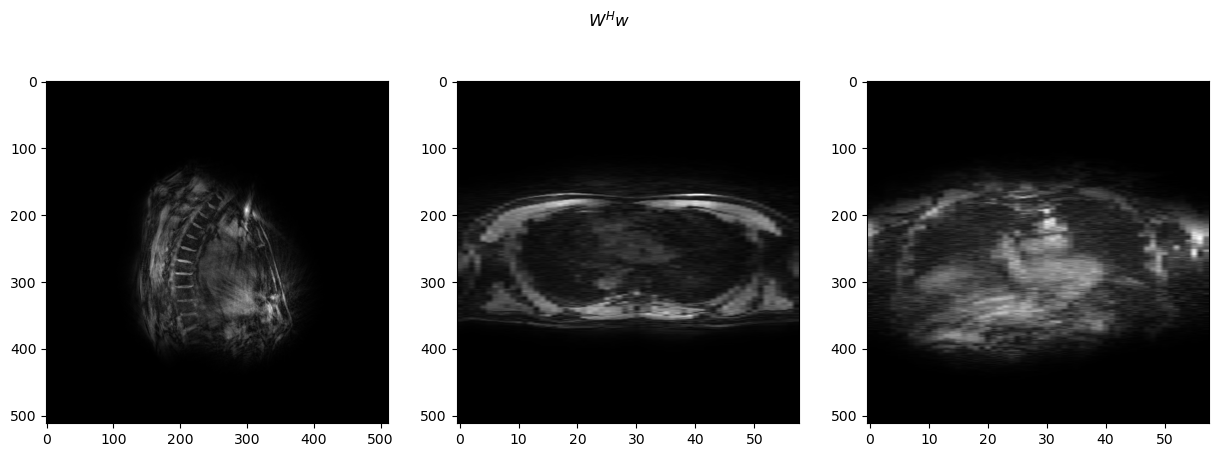

In [7]:
fig, axs = recon_plot_helpers.plot_recons_all_axes(cp.asnumpy(W.H * wav_norm), title=rf'$W^H w$')

## 4. Create Batched Forward Operator for Reconstruction

In [8]:
espirit_mps_gate0.shape[:-3]
coords.shape[:-1]

(22623, 512)

In [9]:
class BatchedForwardOperator:
    """
    Composite operator A = F * S * W.H
    Batches both NUFFT (F) and SENSE (S) operations
    """
    def __init__(self, mps_cpu, coords, img_shape, coil_batch_size, device):
        self.mps_cpu = mps_cpu  # Keep on CPU, load batches as needed
        self.coords = coords
        self.img_shape = img_shape
        self.coil_batch_size = coil_batch_size
        self.device = device
        self.num_coils = mps_cpu.shape[0]
        
        # Wavelet operator (cheap, keep on GPU)
        self.W = sp.linop.Wavelet(img_shape, wave_name='db4', level=4)
        
        # Shapes for compatibility
        self.ishape = self.W.ishape  # Wavelet coefficient shape
        # Output shape: kspace shape for all coils
        nspokes = coords.shape[0]
        nreadout = coords.shape[1]
        self.oshape = [self.num_coils, nspokes, nreadout]
    
    def _apply(self, wav_coeffs):
        """Forward: W.H -> S (batched) -> F (batched)"""
        with sp.Device(self.device):
            # Step 1: W.H - wavelet to image (cheap, single operation)
            img = self.W.H * wav_coeffs
            
            # Step 2 & 3: S and F - batch together since they're both expensive
            ksp_results = []
            
            for coil_start in range(0, self.num_coils, self.coil_batch_size):
                coil_end = min(coil_start + self.coil_batch_size, self.num_coils)
                batch_size = coil_end - coil_start
                
                # Load sensitivity maps for this batch
                mps_batch = sp.to_device(
                    self.mps_cpu[coil_start:coil_end], self.device
                )
                
                # Apply S: multiply image by sensitivity maps
                coil_imgs_batch = cp.zeros(
                    (batch_size,) + tuple(self.img_shape), 
                    dtype=img.dtype
                )
                for i in range(batch_size):
                    coil_imgs_batch[i] = mps_batch[i] * img
                
                # Apply F: NUFFT on coil images
                F_batch = sp.linop.NUFFT(
                    (batch_size,) + tuple(self.img_shape), 
                    coord=self.coords
                )
                ksp_batch = F_batch * coil_imgs_batch
                
                # Store result
                ksp_results.append(ksp_batch)
                
                del mps_batch, coil_imgs_batch, F_batch, ksp_batch
                cp.get_default_memory_pool().free_all_blocks()
            
            # Concatenate all kspace results
            ksp_full = cp.concatenate(ksp_results, axis=0)
            del ksp_results, img
            cp.get_default_memory_pool().free_all_blocks()
            
            return ksp_full
    
    def _adjoint_apply(self, ksp):
        """Adjoint: F.H (batched) -> S.H (batched) -> W"""
        with sp.Device(self.device):
            # Initialize accumulator for combined image (S.H output)
            img_combined = cp.zeros(self.img_shape, dtype=ksp.dtype)
            
            # Steps 1 & 2: F.H and S.H - batch together
            for coil_start in range(0, self.num_coils, self.coil_batch_size):
                coil_end = min(coil_start + self.coil_batch_size, self.num_coils)
                batch_size = coil_end - coil_start
                
                # Get kspace for this batch
                ksp_batch = ksp[coil_start:coil_end]
                
                # Apply F.H: NUFFT adjoint
                F_batch = sp.linop.NUFFT(
                    (batch_size,) + tuple(self.img_shape),
                    coord=self.coords
                )
                coil_imgs_batch = F_batch.H * ksp_batch
                
                # Apply S.H: sum of conj(mps) * coil_imgs
                mps_batch = sp.to_device(
                    self.mps_cpu[coil_start:coil_end], self.device
                )
                
                for i in range(batch_size):
                    img_combined += cp.conj(mps_batch[i]) * coil_imgs_batch[i]
                
                del ksp_batch, F_batch, coil_imgs_batch, mps_batch
                cp.get_default_memory_pool().free_all_blocks()
            
            # Step 3: W - wavelet transform on combined image
            wav_coeffs = self.W * img_combined
            del img_combined
            cp.get_default_memory_pool().free_all_blocks()
            
            return wav_coeffs
    
    def __call__(self, input):
        return self._apply(input)
    
    @property
    def H(self):
        return BatchedAdjointOperator(self)


class BatchedAdjointOperator:
    """Adjoint operator wrapper"""
    def __init__(self, forward_op):
        self.forward_op = forward_op
        self.oshape = forward_op.ishape
        self.ishape = forward_op.oshape
    
    def __call__(self, input):
        return self.forward_op._adjoint_apply(input)
    
    def __mul__(self, input):
        if isinstance(input, (np.ndarray, cp.ndarray)):
            return self(input)
        return NotImplemented

## Create Batched ksp_norm for gradf(x)

In [10]:
with sp.Device(device):
    coords_gpu = sp.to_device(coords, device)

    ## Create batched operator
    A_batched = BatchedForwardOperator(mps, coords_gpu, img_shape,
                                       coil_batch_size=BATCH_SIZE, device=device)
    
    print(A_batched.ishape)
    ksp_norm = A_batched(wav_norm)

[58, 512, 512]


/tmp/ipykernel_3599760/1556252233.py:48: ComplexWarning: Casting complex values to real discards the imaginary part
  coil_imgs_batch[i] = mps_batch[i] * img


In [11]:
print(ksp_norm.shape)

(15, 22623, 512)


# Try recon with BatchedForwardOperator

In [ ]:
lamda = 0.1
alpha = 0.005
max_iter = 30

proxg = sp.prox.L1Reg(A_batched.ishape, lamda=lamda)
wav = wav_norm.astype(np.complex64)

def gradf(x):
    """Gradient function - both forward and adjoint are batched"""
    forward_result = A_batched(x)
    residual = forward_result - ksp_norm
    gradient = A_batched.H(residual)
    
    # Clean up intermediate results
    del forward_result, residual
    cp.get_default_memory_pool().free_all_blocks()
    
    return gradient

print("Starting reconstruction...")
alg = sp.alg.GradientMethod(
    gradf, wav, alpha, proxg=proxg, max_iter=max_iter
)

while not alg.done():
    alg.update()
    print(f'\rL1WaveletRecon, Iteration={alg.iter}/{max_iter}', end='')
    
    # Periodic memory cleanup
    if alg.iter % 5 == 0:
        cp.get_default_memory_pool().free_all_blocks()

print("\nReconstruction complete!")

# Get final image
with sp.Device(device):
    final_img = A_batched.W.H(alg.x)
    final_img = cp.asnumpy(final_img)

proxg = sp.prox.L1Reg((84, 538, 538), lamda=lamda)

with sp.Device(device):
    wav = wav_norm.astype(np.complex64)

def gradf(x):
    """Gradient function - both forward and adjoint are batched"""
    forward_result = A_batched(x)
    residual = forward_result - ksp_norm
    gradient = A_batched.H(residual)
    
    # Clean up intermediate results
    del forward_result, residual
    cp.get_default_memory_pool().free_all_blocks()
    
    return gradient

print("Starting reconstruction...")
alg = sp.alg.GradientMethod(
    gradf, wav, alpha, proxg=proxg, max_iter=max_iter
)

while not alg.done():
    alg.update()
    print(f'\rL1WaveletRecon, Iteration={alg.iter}/{max_iter}', end='')
    
    # Periodic memory cleanup
    if alg.iter % 5 == 0:
        cp.get_default_memory_pool().free_all_blocks()

print("\nReconstruction complete!")

# Get final image
with sp.Device(device):
    final_img = A_batched.W.H(alg.x)
    final_img = cp.asnumpy(final_img)

Starting reconstruction...


/home/lilianae/mambaforge/envs/jointrecon_env_backup_new/lib/python3.10/site-packages/pywt/_multilevel.py:43: UserWarning: Level value of 4 is too high: all coefficients will experience boundary effects.
  warnings.warn(


L1WaveletRecon, Iteration=30/30
Reconstruction complete!


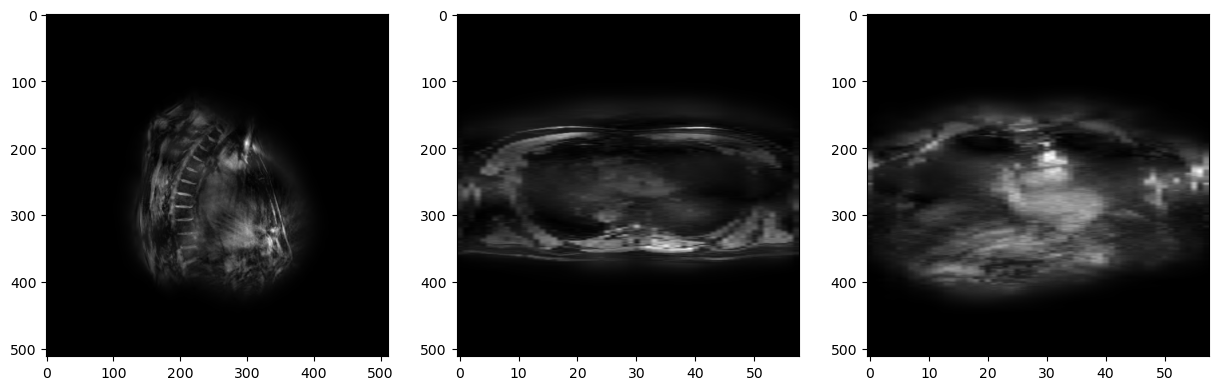

(<Figure size 1500x500 with 3 Axes>,
 array([<AxesSubplot:>, <AxesSubplot:>, <AxesSubplot:>], dtype=object))

In [13]:
recon_plot_helpers.plot_recons_all_axes(final_img)

In [ ]:
print(A_batched.H.ishape)

In [ ]:
wav.shape

In [ ]:
print(gradient.shape)

In [ ]:
print(proxg)

In [ ]:
print(A_batched.ishape)

In [ ]:
print(A_batched.oshape)